<a href="https://colab.research.google.com/github/gustavomoyzzzzz/Entregas-Gustavo-Moya/blob/main/Base_Cargadores_electricos_V_region.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Catastro de Electrolineras con Acceso Público — Región de Valparaíso**
El presente cuaderno forma parte del diagnóstico de infraestructura de carga eléctrica de acceso público desarrollado para la tesis de Ingeniería Comercial. El objetivo es sistematizar y visualizar el estado operativo de los puntos de carga para vehículos eléctricos registrados en la Región de Valparaíso a partir de un catastro de elaboración propia.
La base de datos fue construida a partir de fuentes oficiales y plataformas de monitoreo como la SEC y EcoCarga, reuniendo un total de 130 conectores distribuidos en 37 puntos únicos de carga a lo largo de la región. Cada punto fue caracterizado según su ubicación geográfica, operador, tipo y número de conectores, potencia instalada y estado operativo al momento del levantamiento.
El análisis se desarrolla en dos etapas: primero se presenta la base de datos consolidada por punto único, y luego se georeferencia cada punto mediante un mapa interactivo que permite identificar visualmente la cobertura territorial y el estado operativo de la infraestructura de carga eléctrica de acceso público en la región.

In [6]:
!pip install folium openpyxl

In [8]:
from google.colab import files
import folium
import pandas as pd

uploaded = files.upload()
nombre_archivo = list(uploaded.keys())[0]
df = pd.read_excel(nombre_archivo, sheet_name="Puntos_unicos")
df.head()

Saving Base Electrolinera V region.xlsx to Base Electrolinera V region (2).xlsx


,ID Punto,Nombre del Punto,Comuna,Dirección,Latitud,Longitud,Operador,N° Conectores,Tipos de Conectores,Potencias Presentes (kW),Potencia Máxima (kW),Potencia Nominal Total (kW),Estados Presentes,Estado Final,Cobertura Nominal,Cobertura Efectiva,Potencia Efectiva (kW),Observaciones
0,1,Edificio Chilquinta Barón,Valparaíso,AV. ARGENTINA 1,-33.042573,-71.604823,Chilquinta,2,AC-Tipo 2 (Menneke),44,44.0,88.0,Fuera de línea,Fuera de línea,Sí,No,0.0,NaN
1,2,COPEC Placilla 40098,Valparaíso,Placilla KM 105 Ruta 68,-33.127956,-71.562822,COPEC / Voltex,7,"AC-Tipo 2 (Menneke), CCS Tipo 2, CHAdeMO","43, 50, 180",180.0,863.0,"Disponible, Fuera de línea",Disponible,Sí,Sí,50.0,NaN
2,3,COPEC Llay Llay,Llaillay,Panamericana Norte Km 83 Ruta 5 Poniente S/N,-32.842348,-71.003092,COPEC / Voltex,3,"AC-Tipo 2 (Menneke), CCS Tipo 2, CHAdeMO","43, 50",50.0,143.0,"Disponible, Fuera de línea, No disponible",Disponible,Sí,Sí,50.0,NaN
3,4,COPEC Santo Domingo,Santo Domingo,Teniente Cruz Martinez 70,-33.646155,-71.624596,COPEC / Voltex,3,"AC-Tipo 2 (Menneke), CCS Tipo 2, CHAdeMO","43, 50",50.0,143.0,"Disponible, Fuera de línea",Disponible,Sí,Sí,50.0,NaN
4,5,COPEC 40059 Marbella,Puchuncaví,Ruta F30E Lote CC4 S/N,-32.671447,-71.425912,COPEC / Voltex,4,CCS Tipo 2,180,180.0,720.0,Disponible,Disponible,Sí,Sí,720.0,NaN


El siguiente mapa interactivo georeferencia los 37 puntos únicos de carga para vehículos eléctricos con acceso público registrados en la Región de Valparaíso. Cada punto representa una ubicación física distinta, la cual puede albergar uno o más cargadores de diferentes modelos, potencias y tipos de conector.
Los puntos se clasifican visualmente según su estado operativo al momento del levantamiento: en verde aquellos disponibles u operativos, en rojo los que se encuentran fuera de línea, y en naranjo los catalogados como no disponibles o no operativos. Al hacer clic sobre cada marcador se despliega información detallada del punto, incluyendo comuna, dirección, operador, número de conectores, tipos de conectores disponibles, potencia máxima instalada y potencia efectiva considerando solo los conectores operativos.

In [12]:
mapa = folium.Map(location=[-33.0, -71.3], zoom_start=9, tiles="OpenStreetMap")

def color_estado(estado):
    if estado == "Disponible" or estado == "Operativo":
        return "green"
    elif estado == "Fuera de línea":
        return "orange"
    else:
        return "red"

for _, row in df.iterrows():
    lat = row["Latitud"]
    lon = row["Longitud"]
    nombre = row["Nombre del Punto"]
    comuna = row["Comuna"]
    direccion = row["Dirección"]
    operador = row["Operador"]
    estado = str(row["Estado Final"])
    conectores = row["N° Conectores"]
    tipos = row["Tipos de Conectores"]
    pot_max = row["Potencia Máxima (kW)"]
    pot_efectiva = row["Potencia Efectiva (kW)"]
    color = color_estado(estado)

    popup_html = f"""
    <b style='font-size:14px'>{nombre}</b><br>
    <hr style='margin:4px 0'>
    📍 <b>Comuna:</b> {comuna}<br>
    🏠 <b>Dirección:</b> {direccion}<br>
    🔌 <b>Operador:</b> {operador}<br>
    ⚡ <b>N° Conectores:</b> {conectores}<br>
    🔗 <b>Tipos:</b> {tipos}<br>
    💡 <b>Potencia Máxima:</b> {pot_max} kW<br>
    ✅ <b>Potencia Efectiva:</b> {pot_efectiva} kW<br>
    <b>Estado:</b> <span style='color:{color}'>{estado}</span>
    """

    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(popup_html, max_width=280),
        tooltip=f"{nombre} — {estado}",
        icon=folium.Icon(color=color, icon="bolt", prefix="fa")
    ).add_to(mapa)

leyenda_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background-color:white; padding:12px 16px; border-radius:8px;
     border:2px solid grey; font-size:13px; box-shadow:3px 3px 6px rgba(0,0,0,0.3)">
    <b>Estado Operativo</b><br><br>
    <span style='background-color:green; width:14px; height:14px;
    border-radius:50%; display:inline-block; margin-right:6px'></span> Operativo / Disponible<br><br>
    <span style='background-color:orange; width:14px; height:14px;
    border-radius:50%; display:inline-block; margin-right:6px'></span> Fuera de línea<br><br>
    <span style='background-color:red; width:14px; height:14px;
    border-radius:50%; display:inline-block; margin-right:6px'></span> No disponible / No operativo
</div>
"""
mapa.get_root().html.add_child(folium.Element(leyenda_html))

mapa

# **Sección 1 — Diagnóstico por brecha comunal**

In [13]:
# Tabla resumen por comuna
resumen_comunal = df.groupby("Comuna").agg(
    Total_Puntos=("Nombre del Punto", "count"),
    Operativos=("Estado Final", lambda x: (x == "Disponible").sum()),
    Fuera_Linea=("Estado Final", lambda x: (x == "Fuera de línea").sum()),
    No_Operativos=("Estado Final", lambda x: (x == "No disponible").sum()),
    Potencia_Efectiva_Total=("Potencia Efectiva (kW)", "sum"),
    Potencia_Maxima_Total=("Potencia Máxima (kW)", "sum")
).reset_index()

# Tasa de operatividad por comuna
resumen_comunal["Tasa_Operatividad"] = (
    resumen_comunal["Operativos"] / resumen_comunal["Total_Puntos"] * 100
).round(1)

resumen_comunal.sort_values("Tasa_Operatividad")

,Comuna,Total_Puntos,Operativos,Fuera_Linea,No_Operativos,Potencia_Efectiva_Total,Potencia_Maxima_Total,Tasa_Operatividad
0,Casablanca,1,0,1,0,0.0,22.0,0.0
7,Quilpue,1,0,1,0,0.0,60.0,0.0
11,Vina del Mar,12,4,5,3,694.8,462.0,33.3
10,Valparaíso,5,2,2,1,1050.0,796.0,40.0
8,San Antonio,2,1,1,0,90.0,52.0,50.0
4,Los Andes,3,2,1,0,134.8,89.4,66.7
1,Concón,3,2,1,0,146.5,75.5,66.7
3,Llaillay,2,2,0,0,2050.0,550.0,100.0
6,Quillota,2,2,0,0,568.0,262.0,100.0
5,Puchuncaví,2,2,0,0,1020.0,330.0,100.0


# **Sección 2 — Prioridad A: Recuperación de puntos fuera de línea**  
El siguiente análisis tiene por objetivo identificar las brechas de cobertura de infraestructura de carga eléctrica de acceso público en la Región de Valparaíso, tanto a nivel comunal como territorial. Para ello se distinguen dos tipos de puntos de carga según su función dentro del sistema de movilidad eléctrica regional.
Los puntos de corredor interregional corresponden a cargadores de alta potencia (≥ 500 kW) ubicados sobre rutas troncales como la Ruta 5 Norte, cuya función principal es abastecer viajes de larga distancia entre regiones. Los puntos de uso local y urbano corresponden a cargadores orientados a la movilidad interna de la región, tanto en contextos urbanos como interurbanos locales. Esta distinción es relevante porque la existencia de infraestructura de corredor no resuelve la brecha de movilidad interna comunal, que constituye el foco del presente diagnóstico.

In [14]:
!pip install geopy

In [17]:
# Clasificar puntos según tipo de uso
def clasificar_uso(row):
    if row["Potencia Máxima (kW)"] >= 500:
        return "Corredor interregional"
    else:
        return "Uso local / urbano"

df["Tipo_Uso"] = df.apply(clasificar_uso, axis=1)

# Verificar clasificación
df[["Nombre del Punto", "Comuna", "Potencia Máxima (kW)",
    "Tipo_Uso"]].sort_values("Potencia Máxima (kW)", ascending=False)

,Nombre del Punto,Comuna,Potencia Máxima (kW),Tipo_Uso
34,COPEC 40560,Llaillay,500.0,Corredor interregional
32,Electrolinera Curauma,Valparaíso,300.0,Uso local / urbano
26,"TESLA SUPERCHARGER, ARAUCO PREMIUM OUTLET CURAUMA",Valparaíso,250.0,Uso local / urbano
35,Copec Quillota,Quillota,240.0,Uso local / urbano
1,COPEC Placilla 40098,Valparaíso,180.0,Uso local / urbano
22,Copec Zapallar,Zapallar,180.0,Uso local / urbano
29,COPEC 40046 VOLTEX EDS CONCÓN,Vina del Mar,180.0,Uso local / urbano
4,COPEC 40059 Marbella,Puchuncaví,180.0,Uso local / urbano
30,Enel X - Centro comercial Marbella Maitencillo,Puchuncaví,150.0,Uso local / urbano
24,Copec 40609 voltex VIÑA DEL MAR,Vina del Mar,120.0,Uso local / urbano


La clasificación anterior permite constatar que los puntos de corredor interregional corresponden a los cargadores COPEC 40560 ubicados en Llay Llay sobre la Ruta 5 Norte, con una potencia de 500 kW por conector. Si bien estos puntos forman parte del catastro regional, su función es distinta a la infraestructura de uso local, por lo que el análisis de brecha comunal se realizará sobre los puntos de uso local y urbano, manteniendo los puntos de corredor como referencia complementaria en el mapa.

In [18]:
# Base para análisis de brecha: solo puntos de uso local/urbano
df_local = df[df["Tipo_Uso"] == "Uso local / urbano"].reset_index(drop=True)
operativos_local = df_local[df_local["Estado Final"] == "Disponible"].reset_index(drop=True)

print(f"Total puntos uso local/urbano: {len(df_local)}")
print(f"Operativos: {len(operativos_local)}")
print(f"No operativos: {len(df_local) - len(operativos_local)}")

Total puntos uso local/urbano: 36
Operativos: 20
No operativos: 16


In [19]:
resumen = df_local.groupby("Comuna").agg(
    Total_Puntos=("Nombre del Punto", "count"),
    Operativos=("Estado Final", lambda x: (x == "Disponible").sum()),
    Fuera_Linea=("Estado Final", lambda x: (x == "Fuera de línea").sum()),
    No_Operativos=("Estado Final", lambda x: (x == "No disponible").sum()),
    Potencia_Efectiva_kW=("Potencia Efectiva (kW)", "sum"),
    Potencia_Instalada_kW=("Potencia Máxima (kW)", "sum")
).reset_index()

resumen["Tasa_Operatividad_%"] = (
    resumen["Operativos"] / resumen["Total_Puntos"] * 100
).round(1)

resumen["Potencia_Perdida_kW"] = (
    resumen["Potencia_Instalada_kW"] - resumen["Potencia_Efectiva_kW"]
)

resumen.sort_values("Tasa_Operatividad_%")

,Comuna,Total_Puntos,Operativos,Fuera_Linea,No_Operativos,Potencia_Efectiva_kW,Potencia_Instalada_kW,Tasa_Operatividad_%,Potencia_Perdida_kW
0,Casablanca,1,0,1,0,0.0,22.0,0.0,22.0
7,Quilpue,1,0,1,0,0.0,60.0,0.0,60.0
11,Vina del Mar,12,4,5,3,694.8,462.0,33.3,-232.8
10,Valparaíso,5,2,2,1,1050.0,796.0,40.0,-254.0
8,San Antonio,2,1,1,0,90.0,52.0,50.0,-38.0
4,Los Andes,3,2,1,0,134.8,89.4,66.7,-45.4
1,Concón,3,2,1,0,146.5,75.5,66.7,-71.0
3,Llaillay,1,1,0,0,50.0,50.0,100.0,0.0
6,Quillota,2,2,0,0,568.0,262.0,100.0,-306.0
5,Puchuncaví,2,2,0,0,1020.0,330.0,100.0,-690.0


La tabla anterior permite identificar las comunas con mayor brecha de calidad operativa. Comunas como Valparaíso y Viña del Mar concentran la mayor cantidad de puntos instalados pero presentan tasas de operatividad reducidas, lo que configura una brecha de calidad : existe infraestructura física pero no está disponible para el usuario. Por otro lado, comunas como San Antonio presentan escasa presencia de puntos operativos pese a su relevancia como nodo logístico y su proyección como futuro megapuerto, configurando una brecha de cobertura territorial .

In [22]:
# Escenario 1: solo operativos
operativos = df_local[df_local["Estado Final"] == "Disponible"].reset_index(drop=True)

# Escenario 2: operativos + fuera de línea recuperados
recuperables = df_local[df_local["Estado Final"].isin(["Disponible", "Fuera de línea"])].reset_index(drop=True)

print(f"Escenario actual — Puntos operativos: {len(operativos)}")
print(f"Escenario recuperación — Puntos operativos + recuperables: {len(recuperables)}")
print(f"Puntos que se sumarían al recuperar: {len(recuperables) - len(operativos)}")

Escenario actual — Puntos operativos: 20
Escenario recuperación — Puntos operativos + recuperables: 32
Puntos que se sumarían al recuperar: 12


A continuación se presentan dos mapas complementarios. El primero muestra el estado operativo actual de cada punto de carga, permitiendo identificar de forma clara la distribución territorial y condición de la infraestructura existente. El segundo visualiza los escenarios de cobertura territorial, mostrando qué zonas quedan cubiertas hoy, qué zonas se cubrirían al recuperar los 12 puntos fuera de línea identificados, y qué zonas permanecen sin cobertura en ambos escenarios, constituyendo las áreas prioritarias para la expansión de nueva infraestructura.

In [24]:
mapa_A = folium.Map(location=[-33.0, -71.3], zoom_start=9, tiles="OpenStreetMap")

for _, row in df_local.iterrows():
    color = color_estado(row["Estado Final"])
    popup_html = f"""
    <b style='font-size:14px'>{row['Nombre del Punto']}</b><br>
    <hr style='margin:4px 0'>
    📍 <b>Comuna:</b> {row['Comuna']}<br>
    🏠 <b>Dirección:</b> {row['Dirección']}<br>
    🔌 <b>Operador:</b> {row['Operador']}<br>
    ⚡ <b>N° Conectores:</b> {row['N° Conectores']}<br>
    🔗 <b>Tipos:</b> {row['Tipos de Conectores']}<br>
    💡 <b>Potencia Máxima:</b> {row['Potencia Máxima (kW)']} kW<br>
    ✅ <b>Potencia Efectiva:</b> {row['Potencia Efectiva (kW)']} kW<br>
    <b>Estado:</b> {row['Estado Final']}
    """
    folium.Marker(
        location=[row["Latitud"], row["Longitud"]],
        popup=folium.Popup(popup_html, max_width=280),
        tooltip=f"{row['Nombre del Punto']} — {row['Estado Final']}",
        icon=folium.Icon(color=color, icon="bolt", prefix="fa")
    ).add_to(mapa_A)

# Corredor interregional
for _, row in df[df["Tipo_Uso"] == "Corredor interregional"].iterrows():
    folium.Marker(
        location=[row["Latitud"], row["Longitud"]],
        popup=folium.Popup(f"<b>{row['Nombre del Punto']}</b><br>Corredor interregional<br>Potencia: {row['Potencia Máxima (kW)']} kW", max_width=200),
        tooltip=f"CORREDOR — {row['Nombre del Punto']}",
        icon=folium.Icon(color="blue", icon="road", prefix="fa")
    ).add_to(mapa_A)

leyenda_A = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background-color:white; padding:12px 16px; border-radius:8px;
     border:2px solid grey; font-size:13px; box-shadow:3px 3px 6px rgba(0,0,0,0.3)">
    <b>Estado Operativo</b><br><br>
    <span style='background-color:green; width:14px; height:14px;
    border-radius:50%; display:inline-block; margin-right:6px'></span> Operativo / Disponible<br><br>
    <span style='background-color:orange; width:14px; height:14px;
    border-radius:50%; display:inline-block; margin-right:6px'></span> Fuera de línea<br><br>
    <span style='background-color:red; width:14px; height:14px;
    border-radius:50%; display:inline-block; margin-right:6px'></span> No disponible / No operativo<br><br>
    <span style='background-color:blue; width:14px; height:14px;
    border-radius:50%; display:inline-block; margin-right:6px'></span> Corredor interregional
</div>
"""
mapa_A.get_root().html.add_child(folium.Element(leyenda_A))
mapa_A

In [25]:
# Todas las comunas de la región con al menos un punto en el catastro
comunas_catastro = set(df_local["Comuna"].unique())

# Comunas con al menos un punto operativo hoy
comunas_operativas = set(df_local[df_local["Estado Final"] == "Disponible"]["Comuna"].unique())

# Comunas con al menos un punto recuperable (operativo + fuera de línea)
comunas_recuperables = set(df_local[df_local["Estado Final"].isin(
    ["Disponible", "Fuera de línea"])]["Comuna"].unique())

# Brecha actual: comunas sin ningún punto operativo hoy
sin_cobertura_hoy = comunas_catastro - comunas_operativas

# Brecha residual: comunas que siguen sin cobertura incluso recuperando fuera de línea
sin_cobertura_recuperado = comunas_catastro - comunas_recuperables

print("=" * 50)
print("COMUNAS SIN COBERTURA OPERATIVA HOY:")
for c in sorted(sin_cobertura_hoy):
    print(f"  ❌ {c}")

print("\nCOMUNAS SIN COBERTURA INCLUSO RECUPERANDO FUERA DE LÍNEA:")
for c in sorted(sin_cobertura_recuperado):
    print(f"  🔴 {c} → PRIORIDAD B: requiere nuevo punto")

print("\nCOMUNAS QUE SE RECUPERAN REACTIVANDO FUERA DE LÍNEA:")
recuperables_solo = sin_cobertura_hoy - sin_cobertura_recuperado
for c in sorted(recuperables_solo):
    print(f"  🟡 {c} → PRIORIDAD A: reactivar punto existente")

COMUNAS SIN COBERTURA OPERATIVA HOY:
  ❌ Casablanca
  ❌ Quilpue

COMUNAS SIN COBERTURA INCLUSO RECUPERANDO FUERA DE LÍNEA:

COMUNAS QUE SE RECUPERAN REACTIVANDO FUERA DE LÍNEA:
  🟡 Casablanca → PRIORIDAD A: reactivar punto existente
  🟡 Quilpue → PRIORIDAD A: reactivar punto existente


In [26]:
mapa_B = folium.Map(location=[-33.0, -71.3], zoom_start=9, tiles="OpenStreetMap")

# Escenario 1: cobertura actual (verde)
for _, row in df_local[df_local["Estado Final"] == "Disponible"].iterrows():
    folium.Circle(
        location=[row["Latitud"], row["Longitud"]],
        radius=10000,
        color="green",
        fill=True,
        fill_opacity=0.15,
        tooltip=f"Cobertura actual — {row['Nombre del Punto']}"
    ).add_to(mapa_B)

# Escenario 2: cobertura potencial recuperando fuera de línea (naranja)
for _, row in df_local[df_local["Estado Final"] == "Fuera de línea"].iterrows():
    folium.Circle(
        location=[row["Latitud"], row["Longitud"]],
        radius=10000,
        color="orange",
        fill=True,
        fill_opacity=0.12,
        tooltip=f"Cobertura potencial — {row['Nombre del Punto']}"
    ).add_to(mapa_B)

leyenda_B = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background-color:white; padding:12px 16px; border-radius:8px;
     border:2px solid grey; font-size:13px; box-shadow:3px 3px 6px rgba(0,0,0,0.3)">
    <b>Escenarios de Cobertura (radio 10km)</b><br><br>
    <span style='background-color:green; width:14px; height:14px;
    border-radius:20%; display:inline-block; margin-right:6px; opacity:0.6'></span>
    Escenario actual — puntos operativos<br><br>
    <span style='background-color:orange; width:14px; height:14px;
    border-radius:20%; display:inline-block; margin-right:6px; opacity:0.6'></span>
    Escenario recuperación — fuera de línea reactivados<br><br>
    <i style='color:grey; font-size:11px'>Zonas sin color = brecha territorial → Prioridad B</i>
</div>
"""
mapa_B.get_root().html.add_child(folium.Element(leyenda_B))
mapa_B

Con el fin de establecer un orden de priorización para la recuperación de los puntos fuera de línea, se construye un Índice de Criticidad que combina dos dimensiones: la potencia máxima instalada del punto, que refleja el impacto potencial de su reactivación sobre la capacidad regional de carga, y el tipo de falla, distinguiendo entre puntos fuera de línea —cuya reactivación se estima más viable operativamente— y puntos no disponibles. El índice pondera ambas dimensiones asignando un 60% al criterio de potencia y un 40% al criterio de estado, generando un ranking que permite orientar las decisiones de inversión y gestión hacia los puntos de mayor retorno.

In [27]:
# Índice de criticidad para Prioridad A
df_prioridad_A = df_local[df_local["Estado Final"] != "Disponible"].copy()

# Normalizar potencia recuperable entre 0 y 1
df_prioridad_A["Potencia_Norm"] = (
    df_prioridad_A["Potencia Máxima (kW)"] / df_prioridad_A["Potencia Máxima (kW)"].max()
)

# Penalizar los No disponibles vs Fuera de línea
# Fuera de línea = más fácil de recuperar → mayor prioridad
df_prioridad_A["Puntaje_Estado"] = df_prioridad_A["Estado Final"].map({
    "Fuera de línea": 1.0,
    "No disponible": 0.5
})

# Índice final
df_prioridad_A["Indice_Criticidad"] = (
    df_prioridad_A["Potencia_Norm"] * 0.6 +
    df_prioridad_A["Puntaje_Estado"] * 0.4
).round(3)

df_prioridad_A[["Nombre del Punto", "Comuna", "Estado Final",
                "Potencia Máxima (kW)", "N° Conectores",
                "Indice_Criticidad"]].sort_values(
                "Indice_Criticidad", ascending=False).reset_index(drop=True)

,Nombre del Punto,Comuna,Estado Final,Potencia Máxima (kW),N° Conectores,Indice_Criticidad
0,Electrolinera Curauma,Valparaíso,No disponible,300.0,36,0.800
1,Enel X Way - Espacio Urbano Viña del Mar,Vina del Mar,Fuera de línea,60.0,4,0.520
2,Enel X Way - Petrobras Marga Marga,Quilpue,Fuera de línea,60.0,3,0.520
3,Edificio Chilquinta Barón,Valparaíso,Fuera de línea,44.0,2,0.488
4,INSTALACIÓN SCVE ESTACIONAMIENTOS PLAZA SOTOMAYOR,Valparaíso,Fuera de línea,22.0,2,0.444
5,Cargador Pizeeria Valentini,Concón,Fuera de línea,22.0,2,0.444
6,Oficina Chilquinta San Antonio,San Antonio,Fuera de línea,22.0,1,0.444
7,ELECTROMOVILIDAD EMELCA CASABLANCA,Casablanca,Fuera de línea,22.0,2,0.444
8,Enel X - Casino Enjoy Los Andes,Los Andes,Fuera de línea,22.0,2,0.444
9,Cargador Electrico Jumbo-Easy Vina del Mar,Vina del Mar,Fuera de línea,7.4,1,0.415


El ranking anterior identifica los puntos cuya recuperación tendría mayor impacto sobre la capacidad operativa regional. Los primeros lugares corresponden a puntos con alta potencia instalada y estado fuera de línea, lo que los convierte en candidatos prioritarios para gestiones de mantenimiento o reactivación con el operador correspondiente.

Un aspecto relevante para la sostenibilidad de la infraestructura es la concentración de la gestión entre operadores. El siguiente análisis identifica qué actores controlan la mayor parte de los puntos de carga en la región, qué participación de mercado tienen y cuál es su tasa de falla operativa. Esto permite evaluar si la inoperatividad observada responde a patrones sistemáticos asociados a operadores específicos, lo que tendrían implicancias directas para la política de fiscalización y los requisitos de mantención.

In [28]:
operador_resumen = df_local.groupby("Operador").agg(
    Total_Puntos=("Nombre del Punto", "count"),
    Operativos=("Estado Final", lambda x: (x == "Disponible").sum()),
    No_Operativos=("Estado Final", lambda x: (x != "Disponible").sum()),
    Potencia_Total_kW=("Potencia Máxima (kW)", "sum"),
    Potencia_Efectiva_kW=("Potencia Efectiva (kW)", "sum")
).reset_index()

operador_resumen["Tasa_Falla_%"] = (
    operador_resumen["No_Operativos"] / operador_resumen["Total_Puntos"] * 100
).round(1)

operador_resumen["Participacion_%"] = (
    operador_resumen["Total_Puntos"] / operador_resumen["Total_Puntos"].sum() * 100
).round(1)

operador_resumen.sort_values("Tasa_Falla_%", ascending=False)

,Operador,Total_Puntos,Operativos,No_Operativos,Potencia_Total_kW,Potencia_Efectiva_kW,Tasa_Falla_%,Participacion_%
0,BMW,1,0,1,7.4,0.0,100.0,2.8
3,EMELCA,1,0,1,22.0,0.0,100.0,2.8
6,No identificado,6,0,6,365.4,0.0,100.0,16.7
8,UAI,1,0,1,7.0,0.0,100.0,2.8
2,Chilquinta,3,1,2,88.0,88.0,66.7,8.3
5,Enel X Way,9,5,4,398.2,539.6,44.4,25.0
4,ENEX / SAVE,4,3,1,110.9,246.5,25.0,11.1
1,COPEC / Voltex,10,10,0,1280.0,2310.0,0.0,27.8
7,Tesla,1,1,0,250.0,1000.0,0.0,2.8


La tabla anterior revela la estructura del mercado de infraestructura de carga en la región y permite identificar si existe algún operador con alta participación pero baja tasa de operatividad, lo que configuraría un riesgo sistémico para la cobertura regional. Los operadores con alta tasa de falla y alta participación de mercado deben ser objeto de fiscalización prioritaria o de acuerdos de mantención más exigentes.

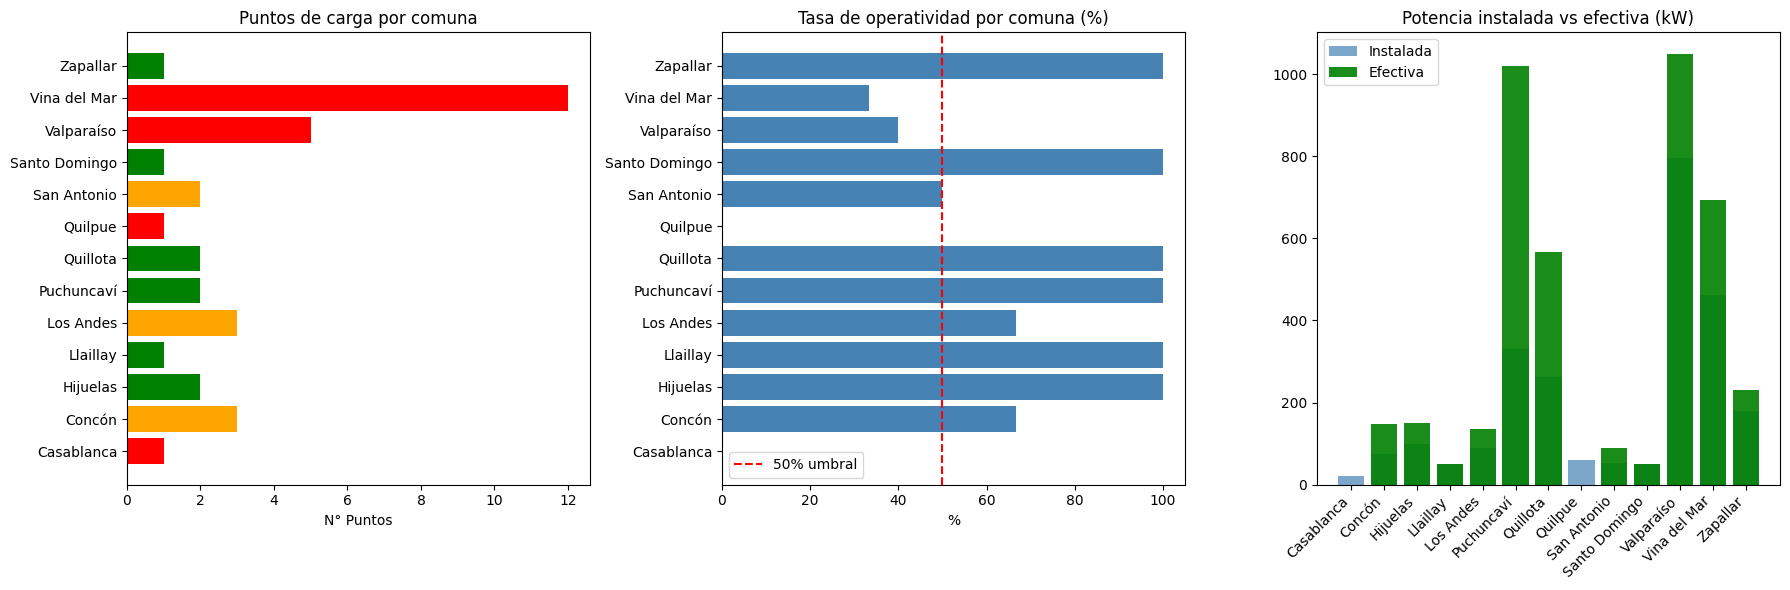

In [29]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 1: Puntos por comuna coloreados por tasa operatividad
colores = ["green" if t == 100 else "orange" if t >= 50 else "red"
           for t in resumen["Tasa_Operatividad_%"]]
axes[0].barh(resumen["Comuna"], resumen["Total_Puntos"], color=colores)
axes[0].set_title("Puntos de carga por comuna")
axes[0].set_xlabel("N° Puntos")

# Gráfico 2: Tasa de operatividad por comuna
axes[1].barh(resumen["Comuna"], resumen["Tasa_Operatividad_%"], color="steelblue")
axes[1].axvline(x=50, color="red", linestyle="--", label="50% umbral")
axes[1].set_title("Tasa de operatividad por comuna (%)")
axes[1].set_xlabel("%")
axes[1].legend()

# Gráfico 3: Potencia instalada vs efectiva por comuna
x = range(len(resumen))
axes[2].bar(x, resumen["Potencia_Instalada_kW"], label="Instalada", alpha=0.7, color="steelblue")
axes[2].bar(x, resumen["Potencia_Efectiva_kW"], label="Efectiva", alpha=0.9, color="green")
axes[2].set_xticks(x)
axes[2].set_xticklabels(resumen["Comuna"], rotation=45, ha="right")
axes[2].set_title("Potencia instalada vs efectiva (kW)")
axes[2].legend()

plt.tight_layout()
plt.savefig("graficos_diagnostico.png", dpi=150, bbox_inches="tight")
plt.show()

Los gráficos anteriores permiten visualizar con claridad que la brecha de infraestructura de carga en la región no responde únicamente a ausencia de puntos instalados, sino en gran medida a la inoperatividad de la infraestructura existente. Comunas con alta potencia instalada pero baja potencia efectiva concentran la mayor pérdida de capacidad regional, lo que refuerza la relevancia de la Prioridad A como primera línea de acción antes de avanzar hacia la expansión de nueva infraestructura.

**A modo de síntesis, se presenta un resumen ejecutivo generado automáticamente a partir de los datos del catastro, que consolida los principales indicadores del diagnóstico regional. Este resumen puede ser utilizado directamente como insumo para la sección de conclusiones o el resumen ejecutivo del informe de tesis.
**


In [33]:
total = len(df_local)
op = len(df_local[df_local["Estado Final"] == "Disponible"])
fl = len(df_local[df_local["Estado Final"] == "Fuera de línea"])
no_op = len(df_local[df_local["Estado Final"] == "No disponible"])

# Potencia correcta: solo desde puntos operativos
pot_efectiva = df_local[df_local["Estado Final"] == "Disponible"]["Potencia Máxima (kW)"].sum()
pot_instalada = df_local["Potencia Máxima (kW)"].sum()
pot_perdida = pot_instalada - pot_efectiva
tasa_op = round(op / total * 100, 1)
tasa_perdida = round(pot_perdida / pot_instalada * 100, 1)

# Resumen comunal
resumen_ejec = df_local.groupby("Comuna").agg(
    Total=("Nombre del Punto", "count"),
    Operativos=("Estado Final", lambda x: (x == "Disponible").sum())
).reset_index()
resumen_ejec["Tasa"] = (resumen_ejec["Operativos"] / resumen_ejec["Total"] * 100).round(1)

# Comunas sin cobertura hoy
sin_cobertura_hoy = resumen_ejec[resumen_ejec["Operativos"] == 0]["Comuna"].tolist()

# Comunas recuperables con Prioridad A
con_fuera_linea = set(df_local[df_local["Estado Final"] == "Fuera de línea"]["Comuna"].unique())
recuperables_A = [c for c in sin_cobertura_hoy if c in con_fuera_linea]

# Prioridad B criterio 1: baja operatividad hoy
baja_operatividad = resumen_ejec[resumen_ejec["Tasa"] < 50]["Comuna"].tolist()

# Prioridad B criterio 2: cobertura insuficiente para demanda futura
cobertura_insuficiente = resumen_ejec[
    (resumen_ejec["Tasa"] >= 50) &
    (resumen_ejec["Operativos"] <= 1)
]["Comuna"].tolist()

# Imprimir resumen ejecutivo
print("RESUMEN EJECUTIVO — INFRAESTRUCTURA DE CARGA ELÉCTRICA V REGIÓN")
print("=" * 65)
print(f"Total puntos de uso local/urbano catastrados : {total}")
print(f"Puntos operativos                            : {op} ({tasa_op}%)")
print(f"Puntos fuera de línea                        : {fl}")
print(f"Puntos no operativos                         : {no_op}")
print()
print(f"Potencia instalada total                     : {pot_instalada:.1f} kW")
print(f"Potencia efectiva disponible                 : {pot_efectiva:.1f} kW")
print(f"Potencia perdida por inoperatividad          : {pot_perdida:.1f} kW ({tasa_perdida}%)")
print()
print(f"Comunas sin cobertura operativa hoy          : {len(sin_cobertura_hoy)} — {sin_cobertura_hoy}")
print(f"Comunas recuperables con Prioridad A         : {len(recuperables_A)} — {recuperables_A}")
print()
print("PRIORIDAD B — Baja operatividad hoy (<50%):")
for c in sorted(baja_operatividad):
    tasa = resumen_ejec[resumen_ejec["Comuna"] == c]["Tasa"].values[0]
    print(f"  → {c}: {tasa}%")
print()
print("PRIORIDAD B — Cobertura insuficiente para demanda futura:")
print("(Operativas hoy pero con un solo punto, vulnerables ante mayor adopcion)")
for c in sorted(cobertura_insuficiente):
    print(f"  → {c}")

RESUMEN EJECUTIVO — INFRAESTRUCTURA DE CARGA ELÉCTRICA V REGIÓN
Total puntos de uso local/urbano catastrados : 36
Puntos operativos                            : 20 (55.6%)
Puntos fuera de línea                        : 12
Puntos no operativos                         : 4

Potencia instalada total                     : 2528.9 kW
Potencia efectiva disponible                 : 1910.3 kW
Potencia perdida por inoperatividad          : 618.6 kW (24.5%)

Comunas sin cobertura operativa hoy          : 2 — ['Casablanca', 'Quilpue']
Comunas recuperables con Prioridad A         : 2 — ['Casablanca', 'Quilpue']

PRIORIDAD B — Baja operatividad hoy (<50%):
  → Casablanca: 0.0%
  → Quilpue: 0.0%
  → Valparaíso: 40.0%
  → Vina del Mar: 33.3%

PRIORIDAD B — Cobertura insuficiente para demanda futura:
(Operativas hoy pero con un solo punto, vulnerables ante mayor adopcion)
  → Llaillay
  → San Antonio
  → Santo Domingo
  → Zapallar
